## Who Worked On This Part?
Aarya Ray Chaudhuri,
Muhammed Azaam Ali

# Cleaning Data With Explained Decisions.

Every step in this notebook comes from a finding in the EDA notebook. For each step we:
1. explain what we change and why,
2. make the change,
3. **check if it actually made the data better**, as the assignment asks.

To check that last part we use the same quick test after every step: two simple models, scored with cross-validation. If a step makes the data better, the models should get better at telling edible from poisonous, or at least not worse. These are not the final models, just a measuring tool.

At the end the cleaned data is saved to `datasets/mushroom_clean.csv` for the predict notebook. `2.5MushroomGraphless.ipynb` does the same cleaning without the graphs and checks.

## Load the data
The CSV files live in `Mushroom/datasets`. Instead of a path that only works on one laptop, we look for the repo folder starting from wherever the notebook runs, and build the full path from there. That way it works for everyone in the team, and later in the deployment pipeline too.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# walk up from where the notebook runs to the repo root, so the data path works on every machine
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Mushroom' / 'datasets').is_dir())
DATA = ROOT / 'Mushroom' / 'datasets'

raw = pd.read_csv(DATA / 'mushroom_project_dataset.csv')
df = raw.copy()
df.shape

(5000, 13)

## Column names and target
The column names use dashes (`cap-diameter`), which means we can't write `df.cap_diameter` and some libraries complain about them. We switch to underscores. We also add the unit to the measurement columns, because stem-width is in mm while the other two are in cm. Without the unit in the name that's easy to forget, especially later in the web form where users type in the values.

The target `class` becomes `is_poisonous` (1 = poisonous, 0 = edible). Poisonous is the positive class because that's the one we must not miss.

In [2]:
df.columns = df.columns.str.replace('-', '_')
df = df.rename(columns={'cap_diameter': 'cap_diameter_cm', 'stem_height': 'stem_height_cm', 'stem_width': 'stem_width_mm'})

df['is_poisonous'] = (df.pop('class') == 'p').astype(int)
num_cols = ['cap_diameter_cm', 'stem_height_cm', 'stem_width_mm']

df.columns.tolist()

['cap_diameter_cm',
 'stem_height_cm',
 'stem_width_mm',
 'spore_print_color',
 'gill_color',
 'habitat',
 'season',
 'ring_type',
 'cap_shape',
 'stem_surface',
 'jumbled_noise_0',
 'jumbled_noise_1',
 'is_poisonous']

## How we check if a step helps
`score()` trains two models on the data and returns their **ROC-AUC**: the chance that the model ranks a random poisonous mushroom as more dangerous than a random edible one. 0.5 is guessing, 1.0 is perfect. We use AUC because it doesn't depend on a threshold and isn't fooled by the 62/38 class split like accuracy is.

- **Logistic regression**: a simple linear model. It's sensitive to skew and to how missing values are filled, so it shows the effect of cleaning well.
- **Random forest**: a tree model. Closer to what we'll probably use later, and it doesn't care about skew.

We use 5-fold cross-validation repeated 3 times (15 scores per model) and report the mean and the spread. The splits are fixed with `random_state`, so every step is tested on the same folds. That lets us compare two steps fold by fold at the end, which is fairer than only looking at the means.

Any NaN that's still left gets filled inside the pipeline (median for numbers, "missing" for text). That way we can score the raw data too, and the filling is learned on the training folds only.

In [3]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# one row per cleaning step, plus the 15 fold scores so we can compare steps fold by fold
steps = {}
fold_aucs = {}

def score(data, step=None):
    X = data.drop(columns='is_poisonous')
    y = data['is_poisonous']
    prep = ColumnTransformer([
        ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), make_column_selector(dtype_include='number')),
        ('cat', make_pipeline(SimpleImputer(strategy='constant', fill_value='missing'), OneHotEncoder(handle_unknown='ignore')), make_column_selector(dtype_exclude='number')),
    ])
    models = {
        'logreg': LogisticRegression(max_iter=2000),
        'forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=42, n_jobs=-1),
    }
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    result = {}
    for name, model in models.items():
        aucs = cross_val_score(make_pipeline(prep, model), X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        result[f'{name}_auc'] = round(aucs.mean(), 4)
        result[f'{name}_std'] = round(aucs.std(), 4)
        if step:
            fold_aucs[(step, name)] = aucs
    if step:
        steps[step] = result
    return result

score(df, '0 raw')

{'logreg_auc': np.float64(0.6922),
 'logreg_std': np.float64(0.0121),
 'forest_auc': np.float64(0.8253),
 'forest_std': np.float64(0.0088)}

This is the starting point: what the models can do with the raw data. The random forest is clearly better than the logistic regression already, which tells us the patterns aren't simple straight lines (makes sense, the EDA showed the signal sits in a few specific values).

## Step 1: drop the noise columns
The EDA showed that `jumbled_noise_0` and `jumbled_noise_1` are shuffled copies of cap-shape: same values, same counts, no real link with the class. Keeping them only gives the models extra chances to learn random patterns.

In [4]:
df = df.drop(columns=['jumbled_noise_0', 'jumbled_noise_1'])
score(df, '1 drop noise')

{'logreg_auc': np.float64(0.6953),
 'logreg_std': np.float64(0.0129),
 'forest_auc': np.float64(0.8357),
 'forest_std': np.float64(0.0088)}

Removing two columns made both models better: the forest goes from 0.825 to 0.836, the logistic regression from 0.692 to 0.695. The noise columns weren't just useless, they were **hurting** the forest, because it was using them to make random splits. Later we check fold by fold that this isn't luck.

## Step 2: duplicate rows
In the EDA there were no duplicates, but that was with the noise columns still in. Now that they're gone, some rows might be exact copies. A real copy can end up in both the training and test part, and then the model is tested on a row it already saw, which makes the score look better than it is.

In [5]:
print('duplicate rows:', df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(df.columns.tolist())

duplicate rows: 5


,cap_diameter_cm,stem_height_cm,stem_width_mm,spore_print_color,gill_color,habitat,season,ring_type,cap_shape,stem_surface,is_poisonous
232,NaN,0.0,0.0,NaN,f,d,w,f,o,f,1
3164,NaN,0.0,0.0,NaN,f,d,w,f,o,f,1
4244,NaN,0.0,0.0,NaN,f,d,w,f,o,f,1
580,NaN,0.0,0.0,NaN,NaN,d,a,f,o,f,1
4082,NaN,0.0,0.0,NaN,NaN,d,a,f,o,f,1
1770,NaN,NaN,NaN,NaN,w,d,NaN,f,x,NaN,0
3851,NaN,NaN,NaN,NaN,w,d,NaN,f,x,NaN,0
316,NaN,NaN,NaN,NaN,NaN,d,a,f,f,NaN,0
3608,NaN,NaN,NaN,NaN,NaN,d,a,f,f,NaN,0


There are 5 duplicates, but look at what they are: rows where most values are missing, like three stemless mushrooms that all lost their cap-diameter. With so few values left, two *different* mushrooms of the same species end up looking the same. These aren't copies of one row, they're separate mushrooms, so we **keep them**. (We also tried dropping them: the scores don't change, so this choice doesn't affect the results either way.)

## Step 3: mushrooms without a stem
The EDA showed that `stem_surface = f` (none) always goes together with a stem height and width of 0. These are mushrooms without a stem. So the columns can fill each other's gaps:
- stem_surface is f → missing stem height/width must be 0
- stem height or width is 0 → missing stem_surface must be f, and the other stem measurement is 0 too

This isn't guessing, it follows from what the values mean. And it's better than what would happen otherwise: the median imputer would give a stemless mushroom a stem of 6 cm.

In [6]:
stemless = df['stem_surface'] == 'f'
zero_stem = (df['stem_height_cm'] == 0) | (df['stem_width_mm'] == 0)

print('stem heights filled:', (stemless & df['stem_height_cm'].isna()).sum())
print('stem widths filled:', (stemless & df['stem_width_mm'].isna()).sum())
print('stem surfaces filled:', (zero_stem & df['stem_surface'].isna()).sum())

df.loc[zero_stem, 'stem_surface'] = 'f'
df.loc[df['stem_surface'] == 'f', ['stem_height_cm', 'stem_width_mm']] = 0

score(df, '3 stemless rule')

stem heights filled: 10
stem widths filled: 3
stem surfaces filled: 4


{'logreg_auc': np.float64(0.6959),
 'logreg_std': np.float64(0.0126),
 'forest_auc': np.float64(0.8366),
 'forest_std': np.float64(0.0089)}

17 values filled, and the score barely moves (forest +0.001). That's expected: only a few values changed, and the stemless group was already easy to recognise from stem_surface. We keep this step anyway because it makes the data **correct**: without it, a stemless mushroom would get a 6 cm stem from the median. Not every cleaning step has to be judged on score alone.

## Step 4: missing values in the categorical columns
Three options:
- **A. "missing" as its own value.** Honest: we don't know, so we say we don't know. For spore_print_color and stem_surface the EDA showed being empty is linked to the class, so this keeps that information.
- **B. fill with the most common value (mode).** Pretends we know the value. With 20% missing in some columns, that pushes a lot of rows into one value.
- **C. drop spore_print_color and stem_surface**, since they're 95% and 67% empty. This was the hunch in the EDA notebook.

We test all three. Option A is what `score()` already does with leftover NaN, so we write it into the data for real.

In [7]:
cat_cols = df.columns.drop(num_cols + ['is_poisonous']).tolist()

option_a = df.copy()
option_a[cat_cols] = option_a[cat_cols].fillna('missing')

option_b = df.copy()
for col in cat_cols:
    option_b[col] = option_b[col].fillna(option_b[col].mode()[0])

option_c = option_a.drop(columns=['spore_print_color', 'stem_surface'])

pd.DataFrame({
    'A missing category': score(option_a),
    'B mode': score(option_b),
    'C drop 2 columns': score(option_c),
}).T

,logreg_auc,logreg_std,forest_auc,forest_std
A missing category,0.6959,0.0126,0.8366,0.0089
B mode,0.6889,0.0135,0.8301,0.0103
C drop 2 columns,0.6565,0.0155,0.8042,0.0108


Option A ("missing" as a value) wins for both models:
- **Mode** costs the forest 0.007. Making up values hides the fact that we didn't know them.
- **Dropping spore_print_color and stem_surface** is clearly the worst: the forest loses 0.032 and the logistic regression 0.039. So the hunch from the EDA notebook ("deleting these 2 columns may be beneficial") turns out to be **wrong**. Even though they're mostly empty, the few values that are there (and the fact that they're empty) carry real information.

This is exactly why we test every step instead of going with a feeling.

In [8]:
df = option_a
# no step score here: this is exactly what score() already did, so it would be the same as step 3
df[cat_cols].isna().sum().sum()

np.int64(0)

## Step 5: missing values in the measurements
cap_diameter_cm is still 40% empty, stem_height_cm 20%, stem_width_mm 8%. Filling all of them with the median would put a big spike at one value. The EDA showed the three measurements are strongly related (cap and stem-width: Spearman 0.85), so we can estimate a missing one from the ones that are there.

We compare three ways to fill them:
- **median**: the simple baseline
- **KNN**: take the average of the 10 most similar mushrooms
- **iterative**: predict each column from the other two with a regression, and repeat a few rounds

To see which one is best we do a test where we know the answer: we hide 20% of the values we *do* have, let each method fill them, and measure how far off it is (median absolute error, in the column's own unit). We work on the log1p scale because the columns are very skewed (see the EDA), and convert back afterwards.

In [9]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer

logged = np.log1p(df[num_cols])
rng = np.random.default_rng(42)
hide = logged.notna() & (rng.random(logged.shape) < 0.2)
with_holes = logged.mask(hide)

imputers = {
    'median': SimpleImputer(strategy='median'),
    'knn': KNNImputer(n_neighbors=10),
    # 10 rounds (the default) isn't enough to converge here, it needs about 14
    'iterative': IterativeImputer(max_iter=25, random_state=42),
}

errors = {}
for name, imputer in imputers.items():
    filled = pd.DataFrame(imputer.fit_transform(with_holes), columns=num_cols, index=df.index)
    # error in real units (cm / mm), only on the values we hid
    errors[name] = {col: np.abs(np.expm1(filled.loc[hide[col], col]) - np.expm1(logged.loc[hide[col], col])).median() for col in num_cols}

pd.DataFrame(errors).round(2)

,median,knn,iterative
cap_diameter_cm,2.65,1.61,1.35
stem_height_cm,1.39,1.33,1.44
stem_width_mm,5.74,4.02,3.58


The iterative imputer is the best for cap_diameter_cm (median error 1.35 cm vs 2.65 cm for the median, about **half**) and for stem_width_mm (3.58 mm vs 5.74 mm). For stem_height_cm all three methods are about the same (~1.4 cm), because stem height is only weakly related to the other two (Spearman ~0.5), so there's less to learn from them. We use the iterative imputer for all three to keep it to one method.

In [10]:
before = df[num_cols].copy()

imputer = IterativeImputer(max_iter=25, random_state=42)
df[num_cols] = np.expm1(imputer.fit_transform(np.log1p(df[num_cols]))).clip(min=0).round(2)

score(df, '5 impute measurements')

{'logreg_auc': np.float64(0.6971),
 'logreg_std': np.float64(0.0129),
 'forest_auc': np.float64(0.8396),
 'forest_std': np.float64(0.0091)}

The forest gains another 0.003, the logistic regression 0.001. Small, but these are 3,400+ values that are now a realistic estimate instead of one median value.

**Note on leakage:** here the imputer learns from all 5000 rows, also the ones that will later be test data. It never sees the label, so no class information leaks into it. But in the final model pipeline (predict notebook) the imputer should be fitted on the training split only, the same way it will have to work for new mushrooms in the web app.

A quick visual check: the filled-in values should look like the real ones, not like a spike or a strange new shape.

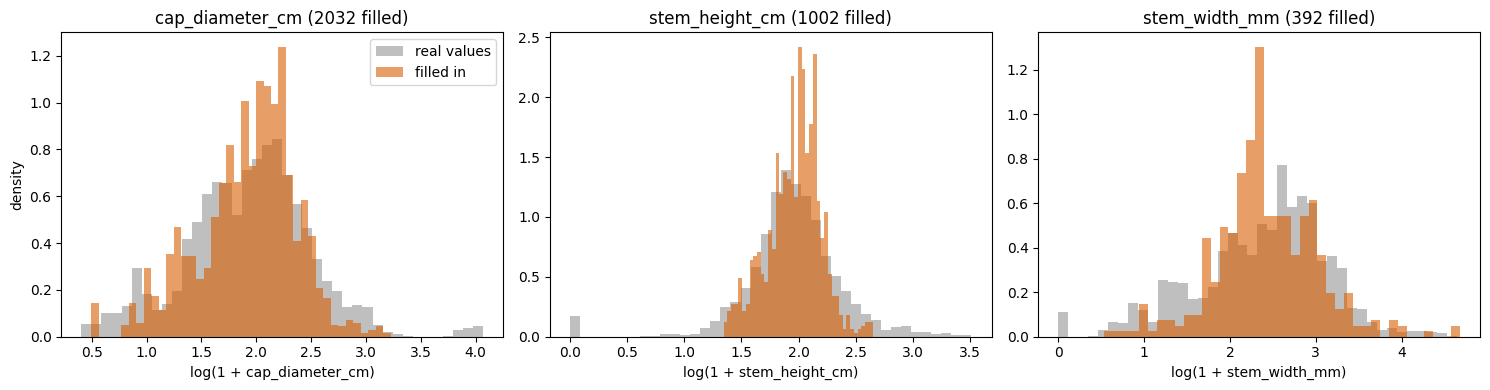

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    was_missing = before[col].isna()
    ax.hist(np.log1p(df.loc[~was_missing, col]), bins=40, alpha=0.5, density=True, color='grey', label='real values')
    ax.hist(np.log1p(df.loc[was_missing, col]), bins=40, alpha=0.6, density=True, color='#d95f02', label='filled in')
    ax.set_title(f'{col} ({was_missing.sum()} filled)')
    ax.set_xlabel(f'log(1 + {col})')
axes[0].set_ylabel('density')
axes[0].legend()
plt.tight_layout()
plt.show()

The filled values follow the same shape as the real ones, but they are **bunched toward the middle**. That makes sense: a regression predicts the typical cap for a given stem, so it rarely fills in an extreme value. Good to know for later: rows with filled-in values look more "average" than they really are. It's not a problem for the models, which only use these values as a rough size hint.

## Step 6: outliers
The EDA found a few hundred values outside the 1.5×IQR range, but also that the big values are real: a group of 31 giant mushrooms (42 to 57 cm caps) that are almost all edible. So we don't want to remove them. Two things we can still try:
- **capping** at the 1st and 99th percentile, which pulls the extreme values in
- **log1p**, which squeezes the long tail without throwing information away

We test both but don't keep either in the data yet; we only check what they do.

In [12]:
capped = df.copy()
for col in num_cols:
    low, high = capped[col].quantile([0.01, 0.99])
    capped[col] = capped[col].clip(low, high)

logged_df = df.copy()
logged_df[num_cols] = np.log1p(logged_df[num_cols])

pd.DataFrame({
    'no change': steps['5 impute measurements'],
    'capped 1-99%': score(capped),
    'log1p': score(logged_df),
}).T

,logreg_auc,logreg_std,forest_auc,forest_std
no change,0.6971,0.0129,0.8396,0.0091
capped 1-99%,0.6949,0.0124,0.8393,0.0090
log1p,0.7016,0.0125,0.8396,0.0091


- **Capping doesn't help**: the logistic regression even gets a little worse, the forest stays the same. Together with the EDA (the giant caps are a real species) that's enough reason to **not cap**.
- **log1p helps the logistic regression** (+0.005) and does nothing for the forest. Trees only look at the order of values, and log doesn't change the order.

So we keep the original units in the cleaned file, because the web app will ask users for cm and mm. log1p will be part of the pipeline for linear models in the predict notebook.

## Step 7: data types and (ordered) categoricals
The assignment asks us to look at ordered categoricals. None of our columns has a real order:
- colors (gill, spore print), shapes, surfaces, ring types and habitats are just names. Is "brown" more than "white"? No.
- **season** looks like it has an order, but it's a circle: winter comes right before spring. If we coded it 1 to 4, winter (4) would look far away from spring (1), which is wrong.

So all categoricals stay unordered, and we give them the pandas `category` type. That saves memory and makes it clear for later which columns are labels and not text.

In [13]:
df[cat_cols] = df[cat_cols].astype('category')
df.dtypes

cap_diameter_cm       float64
stem_height_cm        float64
stem_width_mm         float64
spore_print_color    category
gill_color           category
habitat              category
season               category
ring_type            category
cap_shape            category
stem_surface         category
is_poisonous            int64
dtype: object

## Step 8: the labels
The EDA found rows that are probably labelled wrong: 4 edible mushrooms in the stemless group (the rest is poisonous) and 3 poisonous ones in the giant group (the rest is edible). We **don't** change or delete them, because:
- we can't be sure they're wrong, it's a strong hunch based on how the original dataset was built
- if we only "fix" the obvious ones, the test score later looks better than it really is on new data, which has the same kind of noise
- flipping an edible label to poisonous is fine for safety, but flipping a poisonous one to edible would be dangerous if we're wrong

What we keep in mind for the models: the labels contain noise, so a model that gets close to 100% is probably learning the mistakes too.

In [14]:
stemless_edible = (df['stem_surface'] == 'f') & (df['is_poisonous'] == 0)
giant_poisonous = (df['cap_diameter_cm'] > 40) & (df['is_poisonous'] == 1)
print('stemless but edible:', stemless_edible.sum())
print('giant but poisonous:', giant_poisonous.sum())

stemless but edible: 4
giant but poisonous: 3


## Final check and save
No NaN left, all 5000 rows are still there with the same share of poisonous mushrooms, and the cleaned data is saved for the predict notebook.

The CSV doesn't remember the `category` type, so the predict notebook has to set it again after loading.

In [15]:
print('rows:', len(raw), '->', len(df))
print('columns:', raw.shape[1], '->', df.shape[1])
print('missing values left:', df.isna().sum().sum())
print('share poisonous before / after:', round((raw['class'] == 'p').mean(), 3), '/', round(df['is_poisonous'].mean(), 3))

df.to_csv(DATA / 'mushroom_clean.csv', index=False)
df.head()

rows: 5000 -> 5000
columns: 13 -> 11
missing values left: 0
share poisonous before / after: 0.379 / 0.379


,cap_diameter_cm,stem_height_cm,stem_width_mm,spore_print_color,gill_color,habitat,season,ring_type,cap_shape,stem_surface,is_poisonous
0,7.25,6.42,13.51,missing,missing,d,u,g,x,missing,1
1,6.99,7.68,18.76,missing,w,d,a,f,f,s,0
2,5.78,7.67,8.21,missing,r,d,u,f,c,missing,1
3,6.34,8.34,11.06,missing,missing,d,a,z,x,missing,1
4,7.01,5.67,12.78,missing,n,d,missing,f,x,missing,0


## Did the cleaning help?
All the scores in one table, and the same thing as a graph. Each dot is the mean AUC over the 15 folds, the line is ± 1 standard deviation. The two models get their own panel because their scores are far apart: on one shared axis the changes would be invisible.

                       logreg_auc  logreg_std  forest_auc  forest_std
0 raw                      0.6922      0.0121      0.8253      0.0088
1 drop noise               0.6953      0.0129      0.8357      0.0088
3 stemless rule            0.6959      0.0126      0.8366      0.0089
5 impute measurements      0.6971      0.0129      0.8396      0.0091


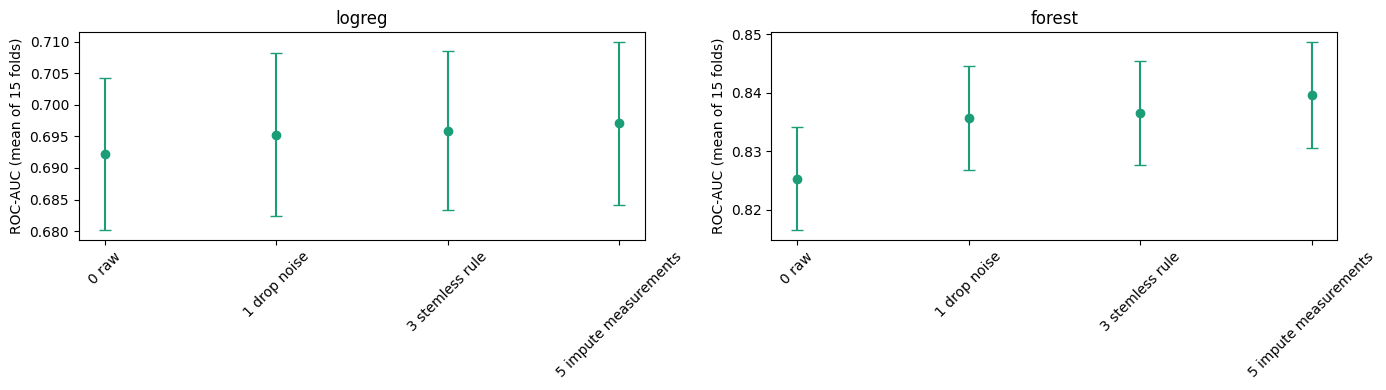

In [16]:
results = pd.DataFrame(steps).T
print(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, model in zip(axes, ['logreg', 'forest']):
    ax.errorbar(results.index, results[f'{model}_auc'], yerr=results[f'{model}_std'], fmt='o', color='#1b9e77', capsize=4)
    ax.set_title(model)
    ax.set_ylabel('ROC-AUC (mean of 15 folds)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The error bars overlap a lot, but they mostly show that some folds are harder than others. Since every step was tested on the same 15 folds, a fairer check is to compare raw vs cleaned **fold by fold**: in how many of the 15 folds did the cleaned data win?

In [17]:
for model in ['logreg', 'forest']:
    gain = fold_aucs[('5 impute measurements', model)] - fold_aucs[('0 raw', model)]
    print(f'{model}: cleaned data wins in {(gain > 0).sum()} of 15 folds, average gain {gain.mean():+.4f}')

gain = fold_aucs[('1 drop noise', 'forest')] - fold_aucs[('0 raw', 'forest')]
print(f'forest, only dropping the noise: wins in {(gain > 0).sum()} of 15 folds, average gain {gain.mean():+.4f}')

logreg: cleaned data wins in 13 of 15 folds, average gain +0.0050
forest: cleaned data wins in 15 of 15 folds, average gain +0.0143
forest, only dropping the noise: wins in 15 of 15 folds, average gain +0.0104


On the cleaned data the forest is better in **15 out of 15 folds**, and so is dropping the noise columns on its own. The logistic regression is better in 13 of 15. So the improvement is small but real, not luck.

# Story
The EDA notebook showed that this dataset is a clean dataset that was damaged on purpose in four ways. In this notebook we tried to repair each one, and the score after every step tells us what each repair was worth.

**1. Fake columns → removed.** This was the biggest single win. The forest went from 0.825 to 0.836 AUC and was better in all 15 folds. Throwing away data made the model better, because those columns only gave it random patterns to learn.

**2. Random gaps → filled, but honestly.** Where the meaning of the data told us the answer we used that (stemless mushrooms have a stem of 0). Where the measurements are related we estimated one from the others, which halved the error for cap diameter compared to the median. And where we really don't know (the categories), we wrote "missing" instead of guessing. Guessing the most common value was worse, and deleting the two mostly-empty columns, which the EDA notebook suggested, was by far the worst option. **Checking every step caught a wrong hunch.**

**3. "Outliers" → not damage at all.** The big values are a real giant species. Capping them didn't help, so we left them alone.

**4. Flipped labels → left as they are.** We can't repair them without guessing, and "fixing" only the ones we can see would make our test scores look better than reality. They set a ceiling on how good any model can get.

**What it adds up to:** the forest went from 0.825 to 0.840 AUC and the logistic regression from 0.692 to 0.697. That's modest, and that's the honest result. Cleaning didn't unlock a lot of hidden accuracy, because what's left in the data is a set of weak signals with noisy labels. What the cleaning did do is remove the parts that were misleading the models, fill 3,400+ gaps in a way that matches how mushrooms actually look, and give a dataset with no NaN and clear names and units. It's ready for the models and for the web form.

**What this means for the predict notebook:**
- The forest is far ahead of the linear model (0.84 vs 0.70). The signal sits in specific combinations of values, not in straight lines, so **tree-based models** (random forest, gradient boosting) are the natural next step.
- Linear models need **log1p** on the measurements.
- The labels are noisy, so a score far above this is suspicious and should be checked for leakage or overfitting.
- **"missing" has to be a valid input** in the web app. Most people won't know a mushroom's spore print color, and the model already knows how to deal with that.
- In the final pipeline the **imputer is fitted on the training data only**.